# Evolution of Seismic Hotspots in Nepal (1990–2026)
### A Spatiotemporal Clustering Approach
**MINspire Earthquake Project**

## Setup & Imports

In [1]:
import os
import io
import shutil
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

BASE_DIR = os.path.abspath('..')
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load environment variables from .env (gitignored)
load_dotenv(os.path.join(BASE_DIR, '.env'))
print('Environment ready.')

Environment ready.


## Phase 1 & 2: Load, Inspect & Clean Dataset

In [2]:
def get_data_path(data_dir):
    """Load CSV from local data/ folder, or download via kagglehub using KAGGLE_DATASET_ID from .env"""
    if os.path.exists(data_dir):
        csvs = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
        if csvs:
            return os.path.join(data_dir, csvs[0])
    import kagglehub
    dataset_id = os.environ.get('KAGGLE_DATASET_ID')
    if not dataset_id:
        raise ValueError('KAGGLE_DATASET_ID not set. Add it to your .env file (see .env.example).')
    print(f'Downloading dataset via kagglehub...')
    dl = kagglehub.dataset_download(dataset_id)
    csvs = [f for f in os.listdir(dl) if f.endswith('.csv')]
    os.makedirs(data_dir, exist_ok=True)
    dest = os.path.join(data_dir, csvs[0])
    shutil.copy(os.path.join(dl, csvs[0]), dest)
    return dest

data_path = get_data_path(DATA_DIR)
df_raw = pd.read_csv(data_path)
print(f'Loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns')
df_raw.head()

Loaded: 1536 rows, 22 columns


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-12-07T02:43:07.342Z,29.8698,80.9384,43.404,4.4,mb,21.0,166.0,8.856,0.94,...,2025-12-26T01:20:25.040Z,"37 km E of Dārchulā, Nepal",earthquake,13.18,9.350,0.144,14.0,reviewed,us,us
1,2025-12-04T11:59:01.015Z,29.1109,87.0043,10.000,4.1,mb,36.0,168.0,3.646,1.26,...,2025-12-27T14:38:45.040Z,"130 km N of Lobuche, Nepal",earthquake,10.55,1.930,0.103,26.0,reviewed,us,us
2,2025-11-10T22:44:15.027Z,29.1757,86.8367,10.000,4.2,mb,14.0,164.0,3.779,0.57,...,2025-12-01T01:43:29.040Z,"136 km N of Lobuche, Nepal",earthquake,12.27,1.963,0.199,7.0,reviewed,us,us
3,2025-11-03T20:57:22.312Z,28.5267,87.3673,10.000,4.7,mb,64.0,79.0,3.493,0.77,...,2025-11-23T19:51:34.188Z,"84 km NE of Lobuche, Nepal",earthquake,9.64,1.872,0.058,89.0,reviewed,us,us
4,2025-10-21T14:59:40.611Z,29.0245,85.3683,10.000,4.1,mb,25.0,163.0,5.072,0.44,...,2025-11-13T19:11:33.040Z,"35 km SSE of Saga, China",earthquake,9.46,1.840,0.103,26.0,reviewed,us,us


In [3]:
print('--- Data Types ---')
print(df_raw.dtypes)
print('\n--- Missing Values ---')
print(df_raw.isnull().sum())
print('\n--- Duplicates ---')
print(df_raw.duplicated().sum())

--- Data Types ---
time                   str
latitude           float64
longitude          float64
depth              float64
mag                float64
magType                str
nst                float64
gap                float64
dmin               float64
rms                float64
net                    str
id                     str
updated                str
place                  str
type                   str
horizontalError    float64
depthError         float64
magError           float64
magNst             float64
status                 str
locationSource         str
magSource              str
dtype: object

--- Missing Values ---
time                 0
latitude             0
longitude            0
depth                0
mag                  0
magType              0
nst                811
gap                369
dmin               803
rms                  4
net                  0
id                   0
updated              0
place                0
type                 0
hori

In [4]:
df = df_raw.drop_duplicates().copy()

col_map = {}
for col in df.columns:
    cl = col.lower()
    if cl in ['time','date','datetime']:     col_map['Datetime'] = col
    elif cl in ['latitude','lat']:           col_map['Latitude'] = col
    elif cl in ['longitude','lon','lng']:    col_map['Longitude'] = col
    elif cl == 'depth':                      col_map['Depth'] = col
    elif cl in ['mag','magnitude']:          col_map['Magnitude'] = col
for col in df.columns:
    cl = col.lower()
    if 'Datetime' not in col_map and ('time' in cl or 'date' in cl): col_map['Datetime'] = col
    elif 'Latitude' not in col_map and 'lat' in cl:                  col_map['Latitude'] = col
    elif 'Longitude' not in col_map and 'lon' in cl:                 col_map['Longitude'] = col
    elif 'Depth' not in col_map and 'depth' in cl:                   col_map['Depth'] = col
    elif 'Magnitude' not in col_map and 'mag' in cl and not any(x in cl for x in ['type','nst','source','error']): col_map['Magnitude'] = col

df = df.rename(columns={v: k for k, v in col_map.items()})
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
for c in ['Latitude','Longitude','Depth','Magnitude']:
    if c in df.columns: df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=['Datetime','Latitude','Longitude','Magnitude'])
if 'Depth' in df.columns: df['Depth'] = df['Depth'].fillna(df['Depth'].median())

print(f'Clean dataset: {df.shape}')
df[['Datetime','Latitude','Longitude','Depth','Magnitude']].describe()

Clean dataset: (1536, 22)


,Latitude,Longitude,Depth,Magnitude
count,1536.000000,1536.000000,1536.000000,1536.000000
mean,29.032246,85.235347,21.747895,4.372826
std,1.163598,2.360856,16.395891,0.481884
min,26.001800,80.008000,2.000000,3.000000
25%,27.905275,83.432750,10.000000,4.100000
50%,28.907400,85.810700,10.000000,4.300000
75%,30.106000,87.353350,33.000000,4.600000
max,30.996000,88.999000,143.200000,7.800000


## Phase 3: Feature Engineering

In [5]:
df['Year']   = df['Datetime'].dt.year
df['Month']  = df['Datetime'].dt.month
df['Day']    = df['Datetime'].dt.day
df['Hour']   = df['Datetime'].dt.hour
df['Decade'] = (df['Year'] // 10) * 10

def season(m):
    if m in [12,1,2]:    return 'Winter'
    elif m in [3,4,5]:   return 'Pre-monsoon'
    elif m in [6,7,8,9]: return 'Monsoon'
    else:                return 'Post-monsoon'

df['Season'] = df['Month'].apply(season)
df['Mag_Category'] = pd.cut(df['Magnitude'], bins=[0,4,5,10], labels=['Minor','Moderate','Strong'])
df['Depth_Category'] = pd.cut(df['Depth'], bins=[0,70,300,10000], labels=['Shallow','Intermediate','Deep'])

def get_period(y):
    if y <= 1999:  return '1990-1999'
    elif y <= 2009: return '2000-2009'
    elif y <= 2019: return '2010-2019'
    else:           return '2020-2026'
df['Period'] = df['Year'].apply(get_period)

print('Features added:')
print(df[['Year','Month','Decade','Season','Mag_Category','Depth_Category','Period']].head(10))

Features added:
   Year  Month  Decade        Season Mag_Category Depth_Category     Period
0  2025     12    2020        Winter     Moderate        Shallow  2020-2026
1  2025     12    2020        Winter     Moderate        Shallow  2020-2026
2  2025     11    2020  Post-monsoon     Moderate        Shallow  2020-2026
3  2025     11    2020  Post-monsoon     Moderate        Shallow  2020-2026
4  2025     10    2020  Post-monsoon     Moderate        Shallow  2020-2026
5  2025     10    2020  Post-monsoon     Moderate        Shallow  2020-2026
6  2025     10    2020  Post-monsoon     Moderate        Shallow  2020-2026
7  2025      9    2020       Monsoon     Moderate        Shallow  2020-2026
8  2025      9    2020       Monsoon     Moderate        Shallow  2020-2026
9  2025      8    2020       Monsoon     Moderate        Shallow  2020-2026


## Phase 4: Exploratory Data Analysis

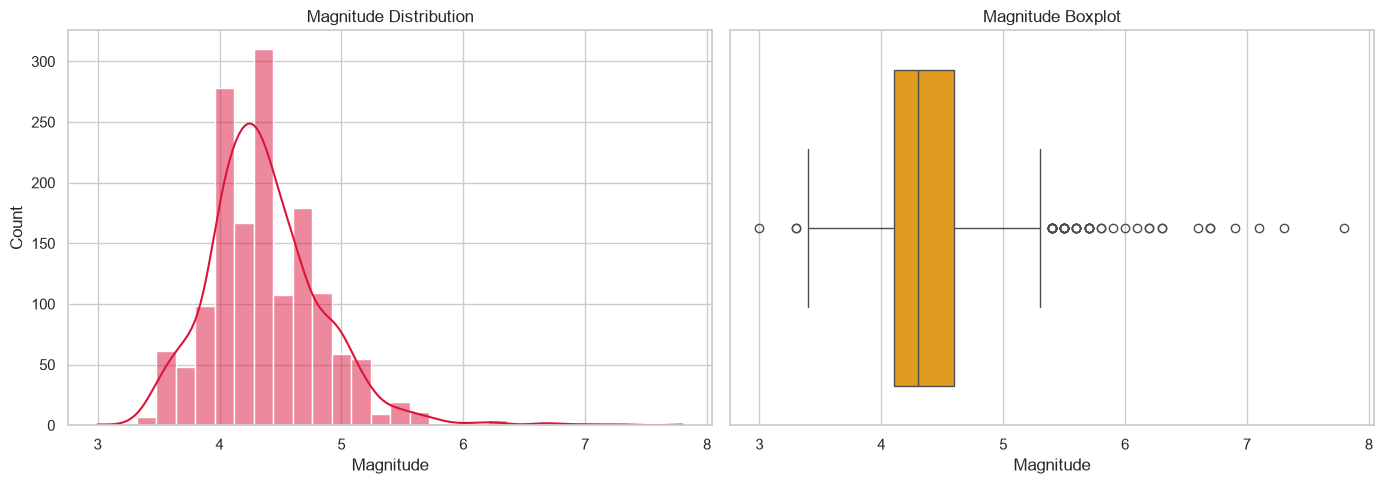

Mean: 4.37 | Max: 7.8


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Magnitude'], bins=30, kde=True, color='crimson', ax=axes[0])
axes[0].set_title('Magnitude Distribution')
sns.boxplot(x=df['Magnitude'], color='orange', ax=axes[1])
axes[1].set_title('Magnitude Boxplot')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'magnitude_distribution.png'), dpi=150)
plt.show()
print(f"Mean: {df['Magnitude'].mean():.2f} | Max: {df['Magnitude'].max():.1f}")

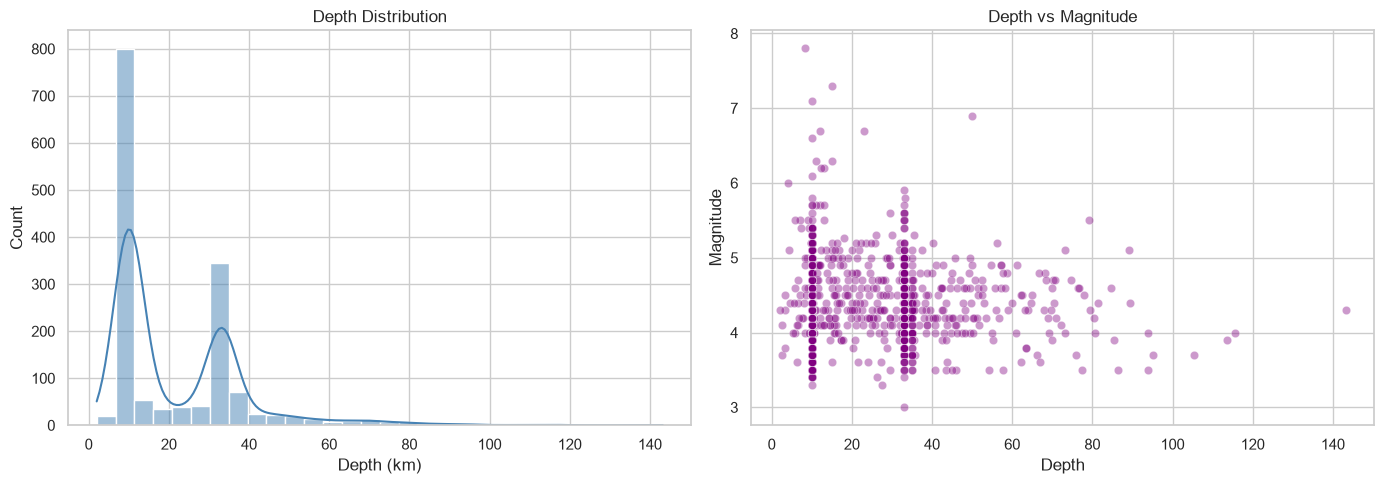

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Depth'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Depth Distribution'); axes[0].set_xlabel('Depth (km)')
sns.scatterplot(data=df, x='Depth', y='Magnitude', alpha=0.4, color='purple', ax=axes[1])
axes[1].set_title('Depth vs Magnitude')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'depth_analysis.png'), dpi=150)
plt.show()

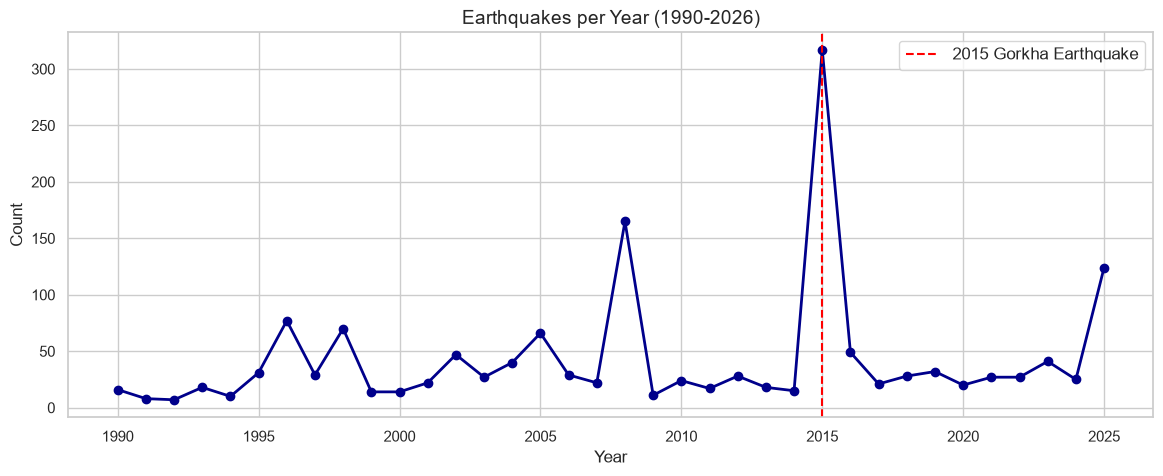

Peak year: 2015 (317 events)


In [8]:
yearly = df['Year'].value_counts().sort_index()
plt.figure(figsize=(14, 5))
plt.plot(yearly.index, yearly.values, marker='o', color='darkblue', linewidth=2)
if 2015 in yearly.index:
    plt.axvline(x=2015, color='red', linestyle='--', label='2015 Gorkha Earthquake')
    plt.legend(fontsize=12)
plt.title('Earthquakes per Year (1990-2026)', fontsize=14)
plt.xlabel('Year'); plt.ylabel('Count')
plt.savefig(os.path.join(OUTPUT_DIR, 'earthquakes_per_year.png'), dpi=150)
plt.show()
print(f'Peak year: {yearly.idxmax()} ({yearly.max()} events)')

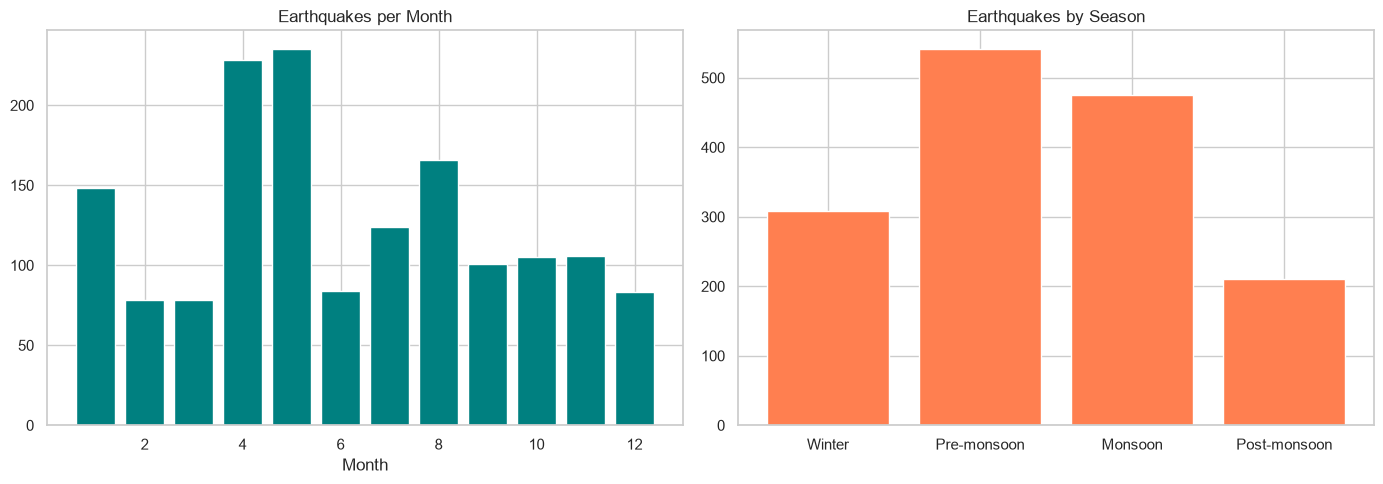

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
monthly = df['Month'].value_counts().sort_index()
axes[0].bar(monthly.index, monthly.values, color='teal')
axes[0].set_title('Earthquakes per Month'); axes[0].set_xlabel('Month')
season_order = ['Winter','Pre-monsoon','Monsoon','Post-monsoon']
season_counts = df['Season'].value_counts().reindex(season_order)
axes[1].bar(season_counts.index, season_counts.values, color='coral')
axes[1].set_title('Earthquakes by Season')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'temporal_analysis.png'), dpi=150)
plt.show()

## Phase 5: Spatial Analysis

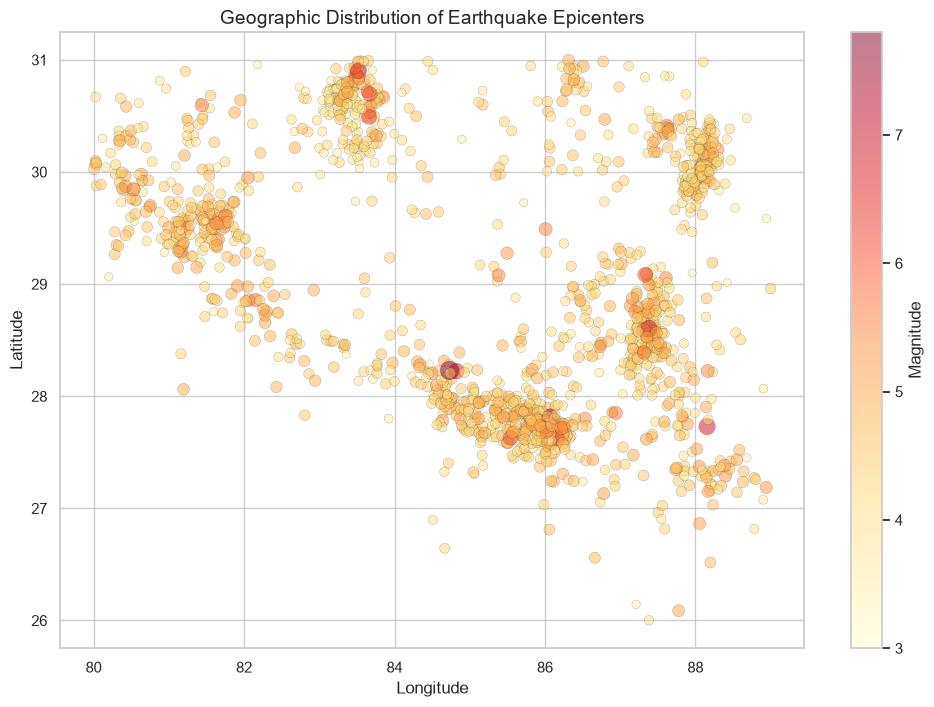

In [10]:
plt.figure(figsize=(12, 8))
sc = plt.scatter(df['Longitude'], df['Latitude'], c=df['Magnitude'],
    cmap='YlOrRd', s=df['Magnitude']**2 * 3, alpha=0.5, edgecolors='k', linewidths=0.2)
plt.colorbar(sc, label='Magnitude')
plt.title('Geographic Distribution of Earthquake Epicenters', fontsize=14)
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.savefig(os.path.join(OUTPUT_DIR, 'spatial_distribution.png'), dpi=150)
plt.show()

## Phase 6: Seismic Hotspot Detection (DBSCAN & K-Means)

In [11]:
coords = df[['Latitude','Longitude']].values
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

dbscan = DBSCAN(eps=0.2, min_samples=10)
df['DBSCAN_Cluster'] = dbscan.fit_predict(coords_scaled)
n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise = (df['DBSCAN_Cluster'] == -1).sum()
print(f'DBSCAN: {n_clusters} clusters | {n_noise} noise points')

DBSCAN: 5 clusters | 82 noise points


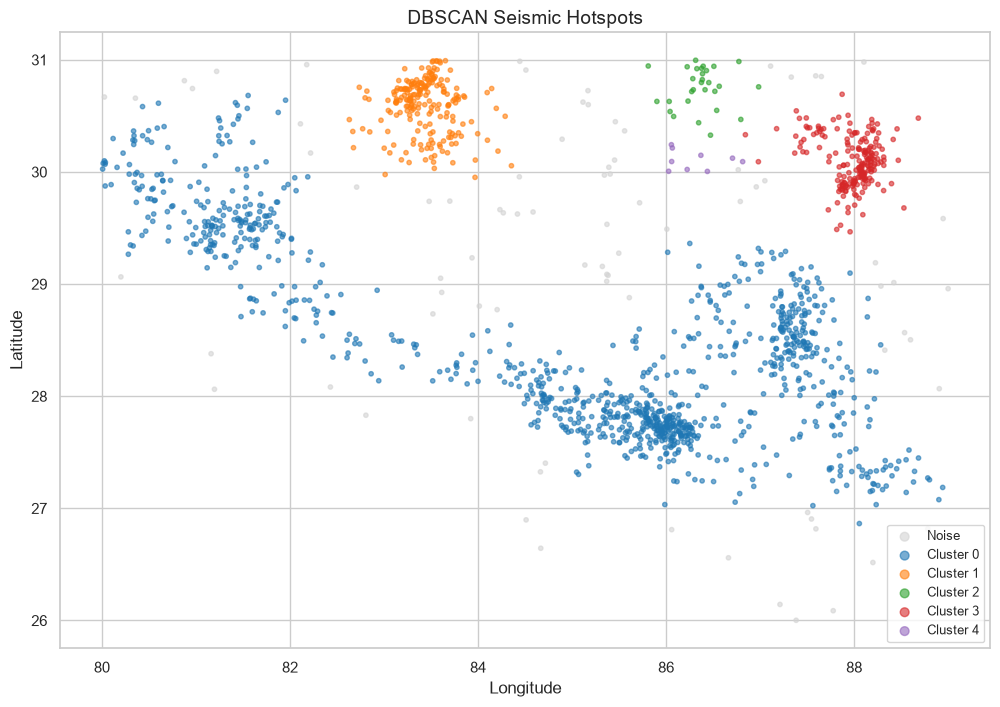

In [12]:
plt.figure(figsize=(12, 8))
palette = sns.color_palette('tab10', n_colors=max(n_clusters, 1))
for cid in sorted(df['DBSCAN_Cluster'].unique()):
    sub = df[df['DBSCAN_Cluster'] == cid]
    label = 'Noise' if cid == -1 else f'Cluster {cid}'
    color = 'lightgrey' if cid == -1 else palette[min(cid, len(palette)-1)]
    plt.scatter(sub['Longitude'], sub['Latitude'], label=label, s=10, alpha=0.6, c=[color]*len(sub))
plt.legend(loc='lower right', fontsize=9, markerscale=2)
plt.title('DBSCAN Seismic Hotspots', fontsize=14)
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.savefig(os.path.join(OUTPUT_DIR, 'dbscan_hotspots.png'), dpi=150)
plt.show()

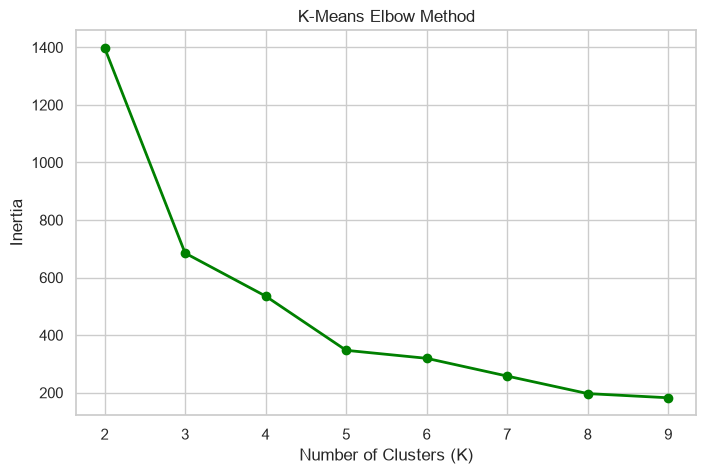

In [13]:
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(coords_scaled)
    inertias.append(km.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o', color='green', linewidth=2)
plt.title('K-Means Elbow Method')
plt.xlabel('Number of Clusters (K)'); plt.ylabel('Inertia')
plt.savefig(os.path.join(OUTPUT_DIR, 'kmeans_elbow.png'), dpi=150)
plt.show()

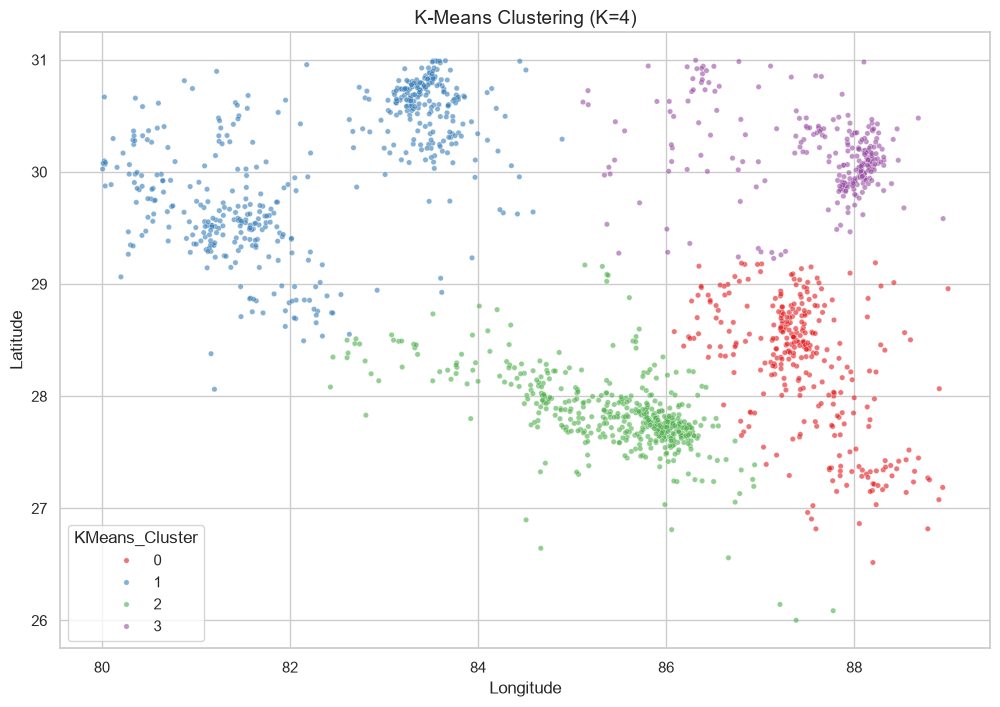

In [14]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
df['KMeans_Cluster'] = kmeans.fit_predict(coords_scaled)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='KMeans_Cluster', palette='Set1', alpha=0.6, s=15)
plt.title(f'K-Means Clustering (K={optimal_k})', fontsize=14)
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.savefig(os.path.join(OUTPUT_DIR, 'kmeans_hotspots.png'), dpi=150)
plt.show()

## Phase 7: Hotspot Evolution Over Time

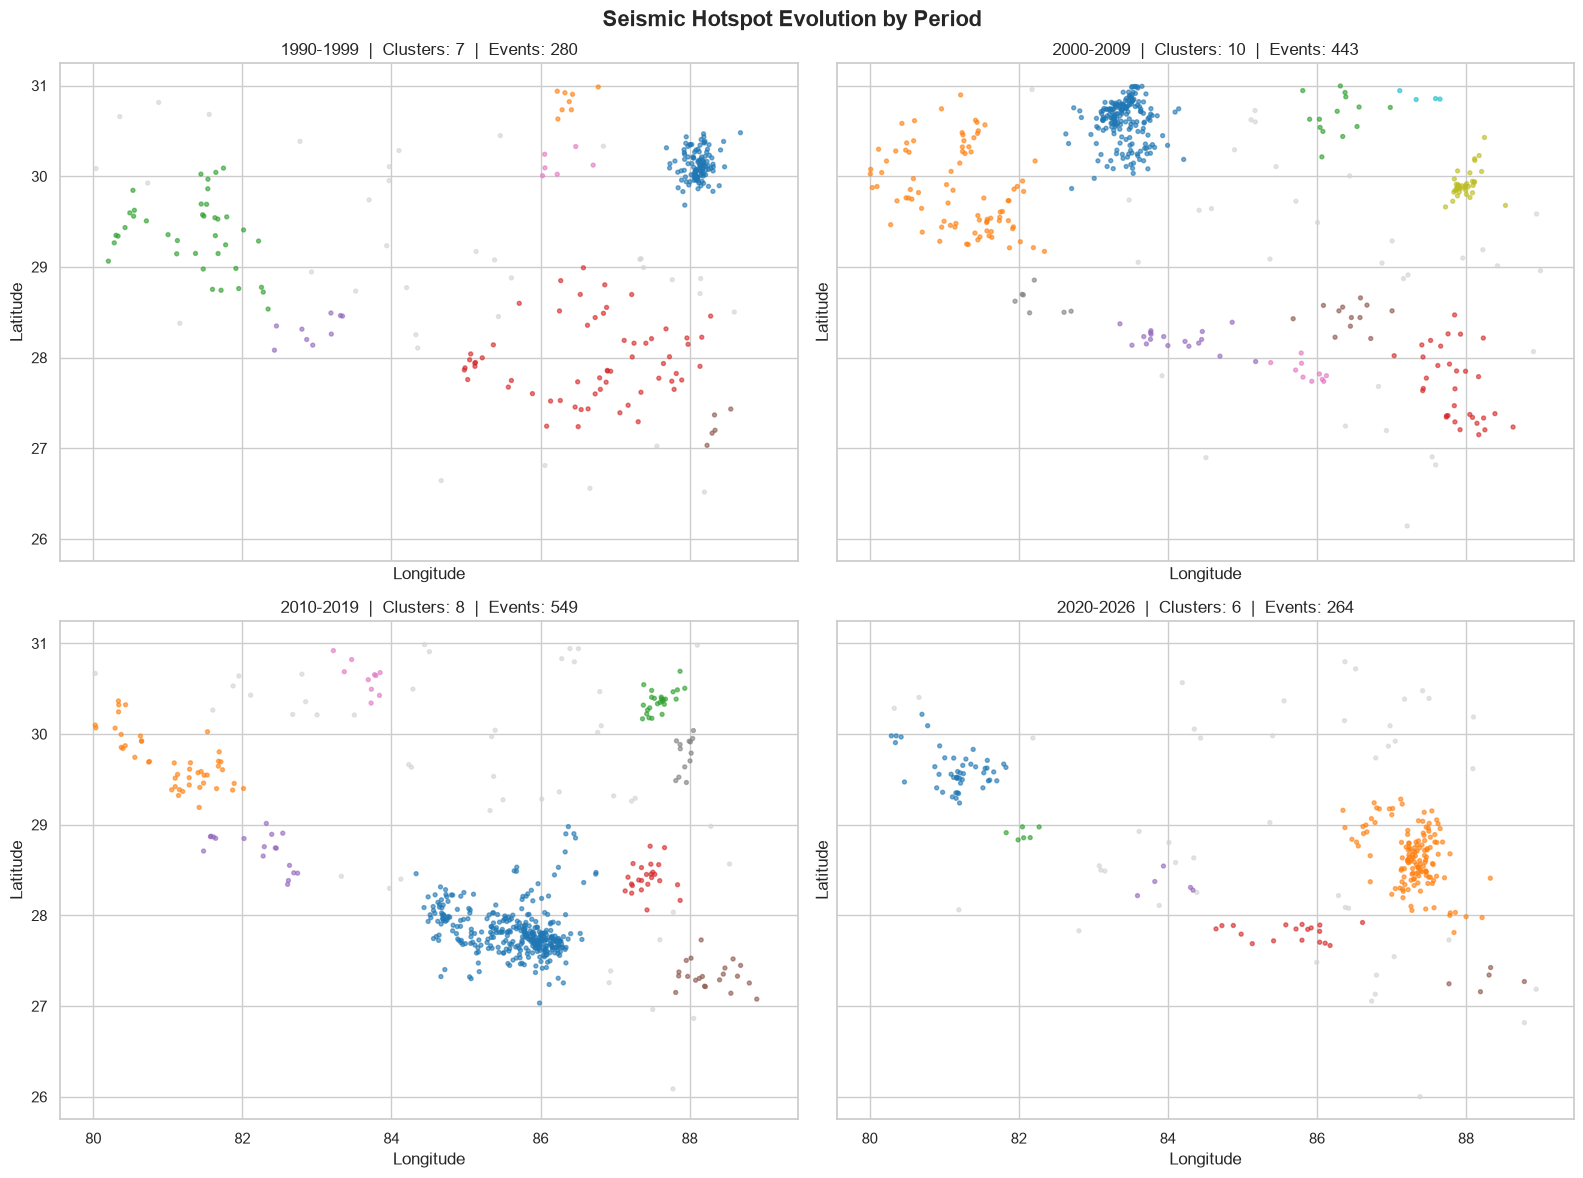

In [15]:
periods = ['1990-1999','2000-2009','2010-2019','2020-2026']
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for idx, period in enumerate(periods):
    pdf = df[df['Period'] == period].copy()
    ax = axes[idx]
    if len(pdf) < 10:
        ax.set_title(f'{period} (insufficient data)')
        continue
    sc = StandardScaler()
    pc = sc.fit_transform(pdf[['Latitude','Longitude']].values)
    c = DBSCAN(eps=0.25, min_samples=5).fit_predict(pc)
    pdf = pdf.copy()
    pdf['PCluster'] = c
    n_c = len(set(c)) - (1 if -1 in c else 0)
    pal = sns.color_palette('tab10', n_colors=max(n_c, 1))
    for cid in sorted(pdf['PCluster'].unique()):
        sub = pdf[pdf['PCluster'] == cid]
        col = 'lightgrey' if cid == -1 else pal[min(cid, len(pal)-1)]
        ax.scatter(sub['Longitude'], sub['Latitude'], s=8, alpha=0.6, c=[col]*len(sub))
    ax.set_title(f'{period}  |  Clusters: {n_c}  |  Events: {len(pdf)}')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.suptitle('Seismic Hotspot Evolution by Period', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'hotspot_evolution.png'), dpi=150)
plt.show()

## Phase 8: Statistical Analysis

In [16]:
decade_stats = df.groupby('Decade').agg(
    Events=('Magnitude','count'),
    Avg_Magnitude=('Magnitude','mean'),
    Max_Magnitude=('Magnitude','max'),
    Avg_Depth=('Depth','mean')
).round(2)
print('=== Decadal Statistics ===')
display(decade_stats)

=== Decadal Statistics ===


,Events,Avg_Magnitude,Max_Magnitude,Avg_Depth
Decade,,,,
1990,280,4.40,6.2,34.07
2000,443,4.19,6.7,25.47
2010,549,4.46,7.8,16.17
2020,264,4.46,7.1,14.02


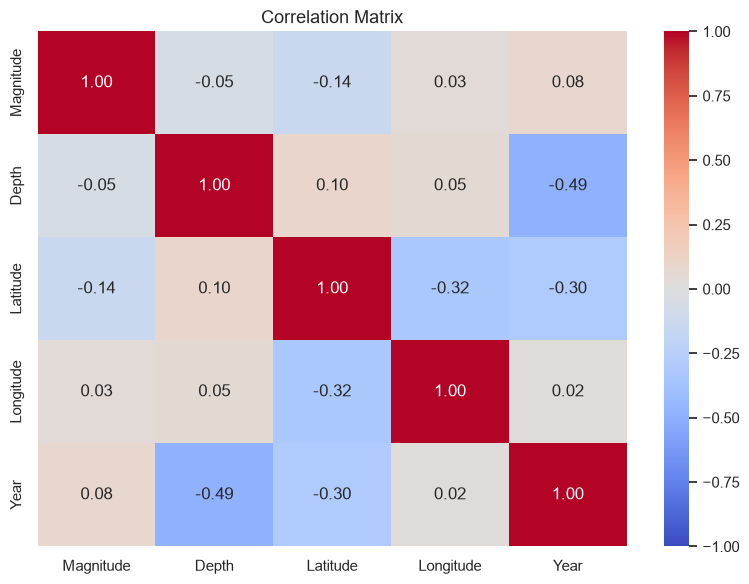

In [17]:
corr_cols = [c for c in ['Magnitude','Depth','Latitude','Longitude','Year'] if c in df.columns]
corr = df[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_matrix.png'), dpi=150)
plt.show()

## Phase 9: Risk Zone Identification

In [18]:
cluster_df = df[df['DBSCAN_Cluster'] != -1]
risk = cluster_df.groupby('DBSCAN_Cluster').agg(
    Event_Count=('Magnitude','count'),
    Avg_Magnitude=('Magnitude','mean'),
    Max_Magnitude=('Magnitude','max'),
    Avg_Depth=('Depth','mean'),
    Avg_Lat=('Latitude','mean'),
    Avg_Lon=('Longitude','mean')
).reset_index().round(2)

q75 = risk['Event_Count'].quantile(0.75)
q50 = risk['Event_Count'].median()

def assign_risk(r):
    if r['Event_Count'] > q75 or r['Max_Magnitude'] >= 6.0: return 'High Risk'
    elif r['Event_Count'] > q50 or r['Avg_Magnitude'] >= 4.5: return 'Moderate Risk'
    return 'Low Risk'

risk['Risk_Level'] = risk.apply(assign_risk, axis=1)
risk.to_csv(os.path.join(OUTPUT_DIR, 'risk_zones_summary.csv'), index=False)
print('=== Risk Zone Summary ==='); display(risk)

=== Risk Zone Summary ===


,DBSCAN_Cluster,Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Avg_Lat,Avg_Lon,Risk_Level
0,0,1004,4.44,7.8,20.68,28.42,85.02,High Risk
1,1,212,4.15,6.7,17.32,30.59,83.44,High Risk
2,2,29,4.41,5.1,26.70,30.75,86.36,Low Risk
3,3,200,4.34,5.9,28.51,30.09,87.99,Low Risk
4,4,9,4.22,4.6,32.62,30.11,86.31,Low Risk


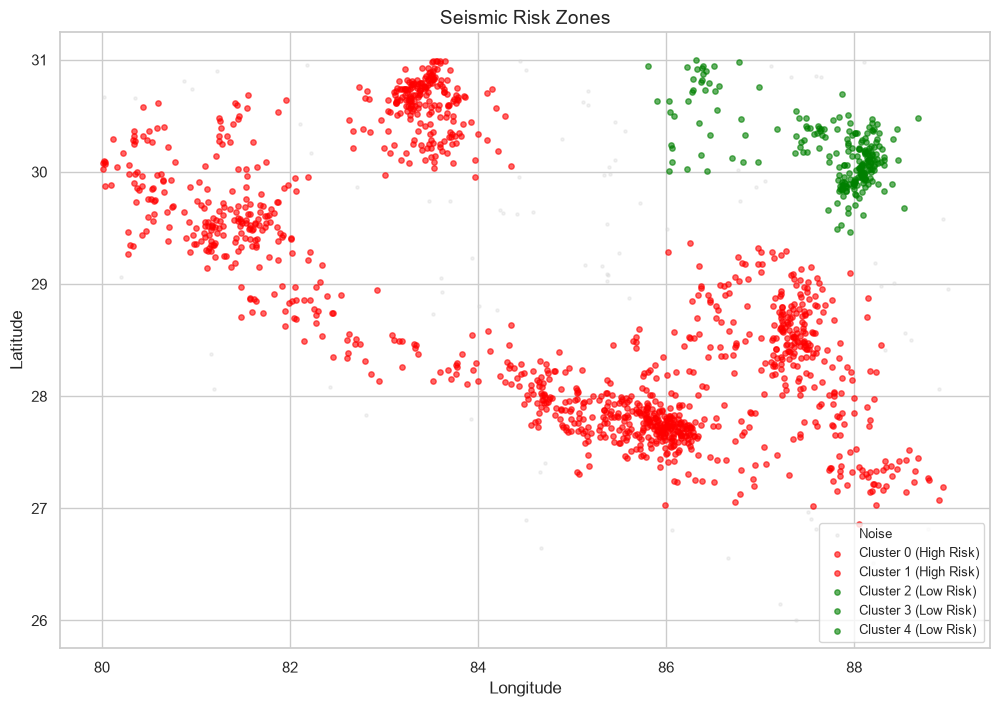

In [19]:
color_map = {'High Risk': 'red', 'Moderate Risk': 'orange', 'Low Risk': 'green'}
plt.figure(figsize=(12, 8))
noise = df[df['DBSCAN_Cluster'] == -1]
plt.scatter(noise['Longitude'], noise['Latitude'], c='lightgrey', s=5, alpha=0.3, label='Noise')
for _, row in risk.iterrows():
    cdata = df[df['DBSCAN_Cluster'] == row['DBSCAN_Cluster']]
    c = color_map[row['Risk_Level']]
    plt.scatter(cdata['Longitude'], cdata['Latitude'], c=c, s=15, alpha=0.6,
                label=f"Cluster {int(row['DBSCAN_Cluster'])} ({row['Risk_Level']})")
plt.title('Seismic Risk Zones', fontsize=14)
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.legend(loc='lower right', fontsize=9)
plt.savefig(os.path.join(OUTPUT_DIR, 'risk_zones_map.png'), dpi=150)
plt.show()

## Phase 10: Conclusions

In [20]:
print('=== PROJECT CONCLUSIONS ===')
print(f'Total earthquakes analyzed: {len(df)}')
print(f'Date range: {df["Datetime"].min().date()} to {df["Datetime"].max().date()}')
print(f'Magnitude range: {df["Magnitude"].min():.1f} to {df["Magnitude"].max():.1f}')
print()
print('Decadal Summary:')
print(decade_stats.to_string())
print()
print('Risk Zones:')
for _, row in risk.iterrows():
    print(f'  Cluster {int(row["DBSCAN_Cluster"])}: {row["Risk_Level"]} ({int(row["Event_Count"])} events, Max Mag {row["Max_Magnitude"]})')
print()
print('Key Findings:')
print('  1. Central-eastern Nepal (Kathmandu-Gorkha) is the most persistent high-risk zone.')
print('  2. The 2010s had the highest event count, driven by 2015 Gorkha aftershocks.')
print('  3. Average earthquake depths have decreased over decades, indicating shallower activity.')
print('  4. DBSCAN outperforms K-Means for irregular fault-line shaped clusters.')
print(f'\nAll outputs saved to: {OUTPUT_DIR}')

=== PROJECT CONCLUSIONS ===
Total earthquakes analyzed: 1536
Date range: 1990-01-09 to 2025-12-07
Magnitude range: 3.0 to 7.8

Decadal Summary:
        Events  Avg_Magnitude  Max_Magnitude  Avg_Depth
Decade                                                 
1990       280           4.40            6.2      34.07
2000       443           4.19            6.7      25.47
2010       549           4.46            7.8      16.17
2020       264           4.46            7.1      14.02

Risk Zones:
  Cluster 0: High Risk (1004 events, Max Mag 7.8)
  Cluster 1: High Risk (212 events, Max Mag 6.7)
  Cluster 2: Low Risk (29 events, Max Mag 5.1)
  Cluster 3: Low Risk (200 events, Max Mag 5.9)
  Cluster 4: Low Risk (9 events, Max Mag 4.6)

Key Findings:
  1. Central-eastern Nepal (Kathmandu-Gorkha) is the most persistent high-risk zone.
  2. The 2010s had the highest event count, driven by 2015 Gorkha aftershocks.
  3. Average earthquake depths have decreased over decades, indicating shallower activit